# Topic classification for English news articles

# 1. Data import

In [17]:
import pandas as pd
import csv

In [18]:
# Import dataset and organize df
art_en_df = pd.read_csv(
    'en_news_data.csv', encoding='utf-8', delimiter=',',
    quotechar='\'', quoting=csv.QUOTE_MINIMAL)

# Set option to display more content in cells
pd.set_option('display.max_colwidth', 500)

art_en_df#.head(3)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,business
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the world economy is worsening. most respondents also said their national economy was getting worse. but when asked about their own family s financial outlook a majority in 14 countries said they were positive about the future. almost 23 000 people in 22 countries were questioned for the poll which was mostly conducted before the asian tsunami disaster. the poll found that a ma...,business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone is not going to help phone firms sell more handsets research suggests. instead phone firms keen to get more out of their customers should not just be pushing the technology for its own sake. consumers are far more interested in how handsets fit in with their lifestyle than they are in screen size onboard memory or the chip inside shows an in-depth study by handset maker ericsson. historically in the industry the...,tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $168m (£89m) settlement deal in a shareholder lawsuit over the collapse of the energy firm. leading plaintiff the university of california announced the news adding that 10 of the former directors will pay $13m from their own pockets. the settlement will be put to the courts for approval next week. enron went bankrupt in 2001 after it emerged it had hidden hundreds of millions of dollars in debt. before its colla...,business
...,...,...,...
1485,857,double eviction from big brother model caprice and holby city actor jeremy edwards have both left the celebrity big brother house in a surprise double eviction on friday. caprice who left in the scheduled fourth eviction having gained just 5% of the public vote afterwards said: i am so happy i am so glad i m out. edwards then left in a surprise eviction with 12% of the vote. nineteen-year-old blazin squad singer kenzie is currently favourite to win the £50 000 charity prize. caprice ...,entertainment
1486,325,dj double act revamp chart show dj duo jk and joel are taking over bbc radio 1 s flagship chart show on sunday adding showbiz news celebrity interviews and between-song banter. they hope to boost ratings for the long-running show which has been overtaken in popularity by independent radio s hit 40 uk rundown. radio 1 s chart show is an institution and remains the station s single most popular show says jk also known as jason king. for years people have been tuning in at four o clock...,entertainment
1487,1590,weak dollar hits reuters revenues at media group reuters slipped 11% during 2004 mainly due to the weakness of the dollar the group said. the company said it was optimistic about growth even as revenues slipped 11% from £3.24bn ($6.13bn) in 2003 to £2.89bn in 2004. reuters beat profit forecasts posting a 52% rise in profits for the year to £198m from the £130m seen 

# 2. EDA and data cleaning

In [19]:
art_en_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.0+ KB


In [20]:
# Check count and unique
art_en_df.describe()

,ArticleId
count,1490.000000
mean,1119.696644
std,641.826283
min,2.000000
25%,565.250000
50%,1112.500000
75%,1680.750000
max,2224.000000


In [21]:
# Check unique categories
art_en_df["Category"].unique()

array(['business', 'tech', 'politics', 'sport', 'entertainment'],
      dtype=object)

In [22]:
# Adapt category labels
art_en_df.loc[art_en_df['Category'] == 'business', 'Category'] = 'Business'
art_en_df.loc[art_en_df['Category'] == 'tech', 'Category'] = 'Tech'
art_en_df.loc[art_en_df['Category'] == 'politics', 'Category'] = 'Politics'
art_en_df.loc[art_en_df['Category'] == 'sport', 'Category'] = 'Sport'
art_en_df.loc[art_en_df['Category'] == 'entertainment', 'Category'] = 'Entertainment & Arts'

art_en_df.head(2)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business


In [23]:
# Check unique categories again
art_en_df["Category"].unique()

array(['Business', 'Tech', 'Politics', 'Sport', 'Entertainment & Arts'],
      dtype=object)

In [24]:
# Check for empty category cells
art_en_df["Category"].isna().sum()

0

In [25]:
# Check for duplicates -> none
art_en_df.duplicated().sum()

0

In [26]:
# Check for duplicates in Text col -> 50
art_en_df["Text"].duplicated().sum()

50

In [27]:
# Find duplicate index
duplicated_text=art_en_df["Text"].duplicated()
# Create df with index numbers in first col and transform the col to a list
duplicated_df = duplicated_text.loc[duplicated_text==True].to_frame().reset_index()
duplicated_list = duplicated_df["index"].tolist()
#duplicated_list

In [28]:
# Find duplicate rows based on indexlist
art_en_df.loc[duplicated_list,:].head(3)

,ArticleId,Text,Category
157,853,prince crowned top music earner prince earned more than any other pop star in 2004 beating artists such madonna and elton john in us magazine rolling stone s annual list. the singer banked $56.5m (£30.4m) from concerts album and publishing sales with his musicology tour and album. he kept madonna in second place as she earned $54.9m (£29.5m) while embarking on her global re-invention tour. veterans simon and garfunkel were in 10th place their comeback tour helping them earn $24.9m (£1...,Entertainment & Arts
208,1022,format wars could confuse users technology firms sony philips matsushita and samsung are developing a common way to stop people pirating digital music and video. the firms want to make a system that ensures files play on the hardware they make but also thwarts illegal copying. the move could mean more confusion for consumers already faced by many different and conflicting content control systems experts warned. they say there are no guarantees the system will even prevent piracy. cu...,Tech
271,302,fox attacks blair s tory lies tony blair lied when he took the uk to war so has no qualms about lying in the election campaign say the tories. tory co-chairman liam fox was speaking after mr blair told labour members the tories offered a hard right agenda . dr fox told bbc radio: if you are willing to lie about the reasons for going to war i guess you are going to lie about anything at all. he would not discuss reports the party repaid £500 000 to lord ashcroft after he predicted an ...,Politics


In [29]:
# Drop rows with identical text (whose index is in duplicated_list)
# So far,this has not been applied. Duplicates are kept. 
# It might make sense to keep them because articles can have more than one topic
# art_en_df = art_en_df.drop(duplicated_list)

In [30]:
# Check again for duplicates -> 0
art_en_df["Text"].duplicated().sum()

50

In [31]:
# Check again count and unique
art_en_df["Text"].describe().to_frame()

,Text
count,1490
unique,1440
top,microsoft seeking spyware trojan microsoft is investigating a trojan program that attempts to switch off the firm s anti-spyware software. the spyware tool was only released by microsoft in the last few weeks and has been downloaded by six million people. stephen toulouse a security manager at microsoft said the malicious program was called bankash-a trojan and was being sent as an e-mail attachment. microsoft said it did not believe the program was widespread and recommended users to use...
freq,2


In [32]:
# List of categories
art_en_df["Category"].unique().tolist()

['Business', 'Tech', 'Politics', 'Sport', 'Entertainment & Arts']

In [33]:
# Count articles per category
art_en_df["Category"].value_counts()

Sport                   346
Business                336
Politics                274
Entertainment & Arts    273
Tech                    261
Name: Category, dtype: int64

In [34]:
# Add col with number of words for each article
art_en_df['WordCount'] = art_en_df['Text'].str.split().str.len()
art_en_df.head(3)

,ArticleId,Text,Category,WordCount
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business,301
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business,325
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the world economy is worsening. most respondents also said their national economy was getting worse. but when asked about their own family s financial outlook a majority in 14 countries said they were positive about the future. almost 23 000 people in 22 countries were questioned for the poll which was mostly conducted before the asian tsunami disaster. the poll found that a ma...,Business,514


Total word count:


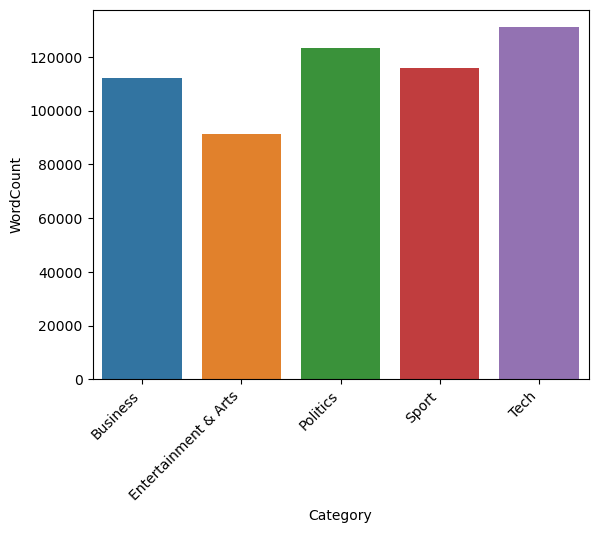

In [35]:
# Total word counts by category
counts=art_en_df.groupby('Category')['WordCount'].sum().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.barplot(x='Category', y='WordCount', data=counts)

# Tilt the bar labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

print("Total word count:")

plt.show()


Average word count:


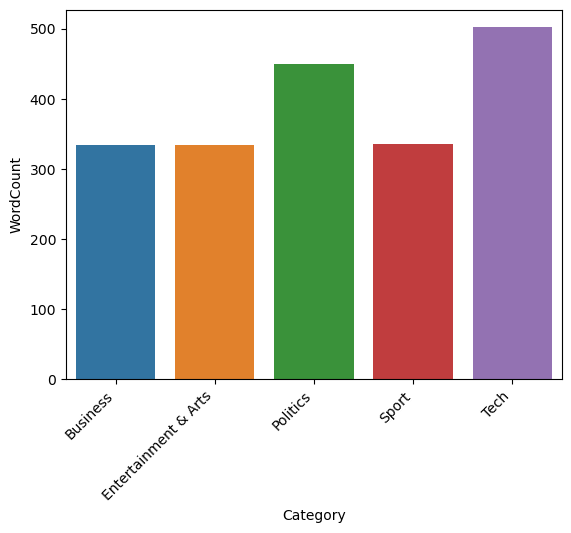

In [36]:
# Average word counts by category
avg_counts=art_en_df.groupby('Category')['WordCount'].mean().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax2=sns.barplot(x='Category', y='WordCount', data=avg_counts)

# Tilt the bar labels
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

print("Average word count:")
plt.show()

In [37]:
# Description of counts by category
desc=art_en_df.groupby('Category')['WordCount'].describe()
desc

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Business,336.0,334.169643,133.527272,145.0,253.00,304.0,391.25,902.0
Entertainment & Arts,273.0,333.912088,203.887349,144.0,229.00,272.0,380.00,2448.0
Politics,274.0,449.689781,258.836242,90.0,319.25,441.5,527.00,3345.0
Sport,346.0,335.346821,185.443084,116.0,210.25,294.5,412.75,1671.0
Tech,261.0,501.858238,211.672986,188.0,340.00,457.0,633.00,1549.0


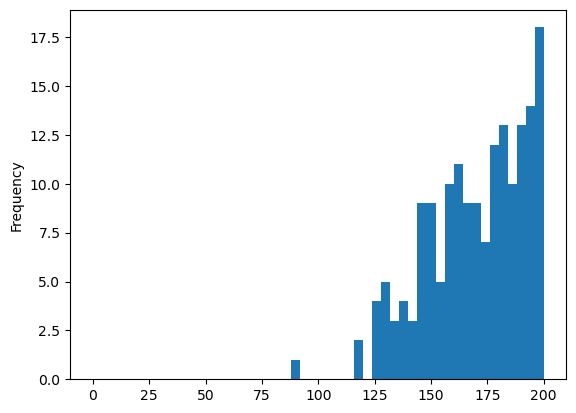

In [38]:
# Hist of WordCounts in range 0 to 200
import matplotlib.pyplot as plt
art_en_df['WordCount'].plot.hist(range=(0, 200), bins=50);

# 3. Text preprocessing

In [39]:
# Create copy of train_df to be used for text preprocessing
art_en_df_prep = art_en_df.copy()

## 3.1 Text cleaning

Removing HTML tags, special characters, punctuation, numbers, and extra whitespaces (but not replaceing umlauts and ß)

In [40]:
import re

# Function: remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub('<.*?>', '', text)
    return clean_text

# Function: remove special characters, numbers, and punctuation
def remove_special_characters(text):
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', text)
    return clean_text

# Function: convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function: remove extra whitespace
def remove_extra_whitespace(text):
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply text cleaning steps to 'text' column
art_en_df_prep['text_cleaned'] = art_en_df_prep['Text'].apply(lambda x: remove_html_tags(x))
art_en_df_prep['text_cleaned'] = art_en_df_prep['text_cleaned'].apply(lambda x: remove_special_characters(x))
art_en_df_prep['text_cleaned'] = art_en_df_prep['text_cleaned'].apply(lambda x: convert_to_lowercase(x))
art_en_df_prep['text_cleaned'] = art_en_df_prep['text_cleaned'].apply(lambda x: remove_extra_whitespace(x))

art_en_df_prep.head(2)


,ArticleId,Text,Category,WordCount,text_cleaned
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business,301,worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in her warnings led to the collapse of the firm following the discovery of an bn bn accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy prosecution l...
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business,325,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy munichbased research institute ifo said that its confidence index fell to in february from in january its first decline in three months the study found that the outlook in both the manufacturing and retail sectors had worsened observers had been hoping that a more confident business sector would signal that economic activity was picking up we re surpri...


## 3.2 Lemmatization

In [41]:
import spacy as sp

2023-06-06 16:39:00.806493: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [42]:
# Load the English language model
nlp = sp.load("en_core_web_sm")

In [43]:
# Function: lemmatize texts/articles (runs for 5 minutes)

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

art_en_df_prep["text_lemmatized"] = art_en_df_prep["text_cleaned"].apply(lemmatize_text)

art_en_df_prep.head(3)

,ArticleId,Text,Category,WordCount,text_cleaned,text_lemmatized
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business,301,worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in her warnings led to the collapse of the firm following the discovery of an bn bn accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy prosecution l...,worldcom exboss launches defence lawyer defend former worldcom chief bernie ebber against a battery of fraud charge have call a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alert director to irregular accounting practice at the us telecom giant in her warning lead to the collapse of the firm follow the discovery of an bn bn accounting fraud mr ebber have plead not guilty to charge of fraud and conspiracy prosecution lawyer have argue th...
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business,325,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy munichbased research institute ifo said that its confidence index fell to in february from in january its first decline in three months the study found that the outlook in both the manufacturing and retail sectors had worsened observers had been hoping that a more confident business sector would signal that economic activity was picking up we re surpri...,german business confidence slide german business confidence fall in february knock hope of a speedy recovery in europe s large economy munichbase research institute ifo say that its confidence index fall to in february from in january its first decline in three month the study find that the outlook in both the manufacturing and retail sector have worsen observer have be hope that a more confident business sector would signal that economic activity be pick up we re surprise that the ifo index...
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the world economy is worsening. most respondents also said their national economy was getting worse. but when asked about their own family s financial outlook a majority in 14 countries said they were positive about the future. almost 23 000 people in 22 countries were questioned for the poll which was mostly conducted before the asian tsunami disaster. the poll found that a ma...,Business,514,bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the world economy is worsening most respondents also said their national economy was getting worse but when asked about their own family s financial outlook a majority in countries said they were positive about the future almost people in countries were questioned for the

**Stemming** is not applied. This is because lemmatization is the preferred method when preserving word meaning is relevant, and usually either lemmatization or stemming is applied, but not both.

## 3.3 Character replacement

In [44]:
# Define a dictionary for character replacement
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

# Function to replace characters in a string
def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

# Apply character replacement to the 'Text' column
art_en_df_prep['text_replaced'] = art_en_df_prep['text_lemmatized'].apply(replace_characters)

art_en_df_prep.head(3)

,ArticleId,Text,Category,WordCount,text_cleaned,text_lemmatized,text_replaced
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business,301,worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in her warnings led to the collapse of the firm following the discovery of an bn bn accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy prosecution l...,worldcom exboss launches defence lawyer defend former worldcom chief bernie ebber against a battery of fraud charge have call a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alert director to irregular accounting practice at the us telecom giant in her warning lead to the collapse of the firm follow the discovery of an bn bn accounting fraud mr ebber have plead not guilty to charge of fraud and conspiracy prosecution lawyer have argue th...,worldcom exboss launches defence lawyer defend former worldcom chief bernie ebber against a battery of fraud charge have call a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alert director to irregular accounting practice at the us telecom giant in her warning lead to the collapse of the firm follow the discovery of an bn bn accounting fraud mr ebber have plead not guilty to charge of fraud and conspiracy prosecution lawyer have argue th...
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business,325,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy munichbased research institute ifo said that its confidence index fell to in february from in january its first decline in three months the study found that the outlook in both the manufacturing and retail sectors had worsened observers had been hoping that a more confident business sector would signal that economic activity was picking up we re surpri...,german business confidence slide german business confidence fall in february knock hope of a speedy recovery in europe s large economy munichbase research institute ifo say that its confidence index fall to in february from in january its first decline in three month the study find that the outlook in both the manufacturing and retail sector have worsen observer have be hope that a more confident business sector would signal that economic activity be pick up we re surprise that the ifo index...,german business confidence slide german business confidence fall in february knock hope of a speedy recovery in europe s large economy munichbase research institute ifo say that its confidence index fall to in february from in january its first decline in three month the study find that the outlook in both the manufacturing and retail sector have worsen observer have be hope that a mor

## 3.4 Stopword removal

In [45]:
nlp = sp.load('en_core_web_sm')

In [46]:
# Function for stopword removal
def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# Call function, adding a new col to df
art_en_df_prep['text_stopwords_removed'] = art_en_df_prep['text_lemmatized'].apply(remove_stopwords)

art_en_df_prep.head(3)

,ArticleId,Text,Category,WordCount,text_cleaned,text_lemmatized,text_replaced,text_stopwords_removed
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. cynthia cooper worldcom s ex-head of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and co...,Business,301,worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alerted directors to irregular accounting practices at the us telecoms giant in her warnings led to the collapse of the firm following the discovery of an bn bn accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy prosecution l...,worldcom exboss launches defence lawyer defend former worldcom chief bernie ebber against a battery of fraud charge have call a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alert director to irregular accounting practice at the us telecom giant in her warning lead to the collapse of the firm follow the discovery of an bn bn accounting fraud mr ebber have plead not guilty to charge of fraud and conspiracy prosecution lawyer have argue th...,worldcom exboss launches defence lawyer defend former worldcom chief bernie ebber against a battery of fraud charge have call a company whistleblower as their first witness cynthia cooper worldcom s exhead of internal accounting alert director to irregular accounting practice at the us telecom giant in her warning lead to the collapse of the firm follow the discovery of an bn bn accounting fraud mr ebber have plead not guilty to charge of fraud and conspiracy prosecution lawyer have argue th...,worldcom exboss launches defence lawyer defend worldcom chief bernie ebber battery fraud charge company whistleblower witness cynthia cooper worldcom s exhead internal accounting alert director irregular accounting practice telecom giant warning lead collapse firm follow discovery bn bn accounting fraud mr ebber plead guilty charge fraud conspiracy prosecution lawyer argue mr ebber orchestrate series accounting trick worldcom order employee hide expense inflate revenue meet wall street earni...
1,154,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking...,Business,325,german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy munichbased research institute ifo said that its confidence index fell to in february from in january its first decline in three months the study found that the outlook in both the manufacturing and retail sectors had worsened observers had been hoping that a more confident business sector would signal that economic activity was picking up we re surpri...,german business confidence slide german business confidence fall in february knock hope of a speedy recovery in europe s large economy munichbase research institute ifo say that its confidence index fall to in february from in january its first decline in three month the study find that the outlook in both the manufacturing and retail sector have worsen observer 

1. Text Cleaning:
- Remove HTML tags (if present).
- Remove special characters and symbols that are not relevant to the analysis.
- Remove punctuation marks.
- Remove any URLs or hyperlinks.

2. Tokenization:
- Split the text into individual words or tokens. 
- Consider using a tokenizer specifically designed for German text, such as the tokenizer provided by the Natural Language Toolkit (NLTK) or the SpaCy library.

3. Lowercasing:
- Convert all text to lowercase. This ensures that words with the same meaning but different cases are treated as the same.

4. Stopword Removal:
- Remove common German stopwords (e.g., "und", "oder", "aber") that do not carry significant meaning and may not contribute much to the classification task.
- Consider using a predefined list of German stopwords or a library like NLTK or SpaCy that provides stopwords for multiple languages.

5. Lemmatization or Stemming:
- Apply lemmatization or stemming to reduce words to their base or root form.
- Choose between lemmatization (preferable for accuracy and interpretability) or stemming (faster but less linguistically accurate).
- Utilize a German-specific lemmatizer or stemmer, such as those available in SpaCy or the Snowball stemmer for German.

6. Removal of Rare or Frequent Words:
- Remove very rare or very frequent words that may not provide much discriminatory power in classification.
- Consider setting thresholds based on the document frequency or term frequency-inverse document frequency (TF-IDF) values to filter out such words.

7. Handling German-specific Challenges:
- Address German-specific challenges like compound words, umlauts, and diacritical marks.
- Consider preprocessing steps such as splitting compound words, handling umlauts, and normalizing diacritical marks to ensure consistency.

8. Vectorization:
- Convert the preprocessed text into numerical features that can be used as input for machine learning algorithms.
- Common techniques include bag-of-words (BoW), TF-IDF, or word embeddings like Word2Vec or GloVe.

# 4. Train-test split

In [47]:
# Copy df before further processing
art_en_df_split = art_en_df_prep.copy()

## 4.1 Remove columns

In [48]:
# Remove col not required
art_en_df_split = art_en_df_split[['Category', 'text_stopwords_removed']]
art_en_df_split.head(2)

,Category,text_stopwords_removed
0,Business,worldcom exboss launches defence lawyer defend worldcom chief bernie ebber battery fraud charge company whistleblower witness cynthia cooper worldcom s exhead internal accounting alert director irregular accounting practice telecom giant warning lead collapse firm follow discovery bn bn accounting fraud mr ebber plead guilty charge fraud conspiracy prosecution lawyer argue mr ebber orchestrate series accounting trick worldcom order employee hide expense inflate revenue meet wall street earni...
1,Business,german business confidence slide german business confidence fall february knock hope speedy recovery europe s large economy munichbase research institute ifo confidence index fall february january decline month study find outlook manufacturing retail sector worsen observer hope confident business sector signal economic activity pick surprise ifo index knock dz bank economist bernd weidensteiner main reason probably domestic economy weak particularly retail trade economy labour minister wolfg...


## 4.2 Define X and y

In [49]:
# Define y
y = art_en_df_split.pop("Category")

# print(y.tolist())

In [50]:
# Define X
X = art_en_df_split
X.head(2)

,text_stopwords_removed
0,worldcom exboss launches defence lawyer defend worldcom chief bernie ebber battery fraud charge company whistleblower witness cynthia cooper worldcom s exhead internal accounting alert director irregular accounting practice telecom giant warning lead collapse firm follow discovery bn bn accounting fraud mr ebber plead guilty charge fraud conspiracy prosecution lawyer argue mr ebber orchestrate series accounting trick worldcom order employee hide expense inflate revenue meet wall street earni...
1,german business confidence slide german business confidence fall february knock hope speedy recovery europe s large economy munichbase research institute ifo confidence index fall february january decline month study find outlook manufacturing retail sector worsen observer hope confident business sector signal economic activity pick surprise ifo index knock dz bank economist bernd weidensteiner main reason probably domestic economy weak particularly retail trade economy labour minister wolfg...


## 4.3 Split

In [51]:
from sklearn.model_selection import train_test_split

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)


In [52]:
len(X_train)

1341

In [53]:
len(y_train)

1341

# 5. Support Vector Machine

In [54]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.feature_selection import RFE
from nltk.tokenize import word_tokenize

## 5.1 Create pipeline and fit training data

In [55]:
# Define the pipeline
my_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()), # tokenizer=word_tokenize
    #('rfe', RFE(estimator=LinearSVC())), # Recursive feature selection
    ('classifier', LinearSVC())
])

# Fit the pipeline to the training data
my_pipeline.fit(X_train["text_stopwords_removed"], y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer()), ('classifier', LinearSVC())])

In [56]:
# Vectorization and prediction for training data
my_pipeline.predict(X_train["text_stopwords_removed"])

array(['Sport', 'Tech', 'Politics', ..., 'Sport', 'Business', 'Tech'],
      dtype=object)

## 5.2 Cross-validation

In [57]:
param_grid = {
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.9],
    'classifier__C': [0.1, 1, 10],
    'classifier__loss': ['squared_hinge'],
    'classifier__penalty': ['l2'],
    'classifier__class_weight': [None]
    }

In [58]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(my_pipeline,
                      param_grid,
                      cv=5, # value for K in K-fold Cross Validation
                      scoring='accuracy', # performance metric to use, 
                     ) # verbose=1 we want informative outputs during the training process


In [59]:
# Fit "search" to training data (X and y)
search.fit(X_train["text_stopwords_removed"], y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('classifier', LinearSVC())]),
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__class_weight': [None],
                         'classifier__loss': ['squared_hinge'],
                         'classifier__penalty': ['l2'], 'tfidf__max_df': [0.9],
                         'tfidf__min_df': [1, 2, 3]},
             scoring='accuracy')

In [60]:
search.best_params_

{'classifier__C': 10,
 'classifier__class_weight': None,
 'classifier__loss': 'squared_hinge',
 'classifier__penalty': 'l2',
 'tfidf__max_df': 0.9,
 'tfidf__min_df': 1}

In [61]:
# Save trained model to file
import pickle

with open('my_en_model.pkl', 'wb') as file:
    pickle.dump(search, file)

## 5.3 Metrics

In [62]:
from sklearn.metrics import accuracy_score

In [63]:
# Accuracy for training data
y_train_pred = search.predict(X_train["text_stopwords_removed"])
#y_train_pred = my_pipeline.predict(X_train["text_stopwords_removed"])

accuracy_score(y_train, y_train_pred)

1.0

In [64]:
# Accuracy for test data
y_test_pred = search.predict(X_test["text_stopwords_removed"])
#y_test_pred = my_pipeline.predict(X_test["text_stopwords_removed"])

accuracy_score(y_test, y_test_pred)

0.9798657718120806

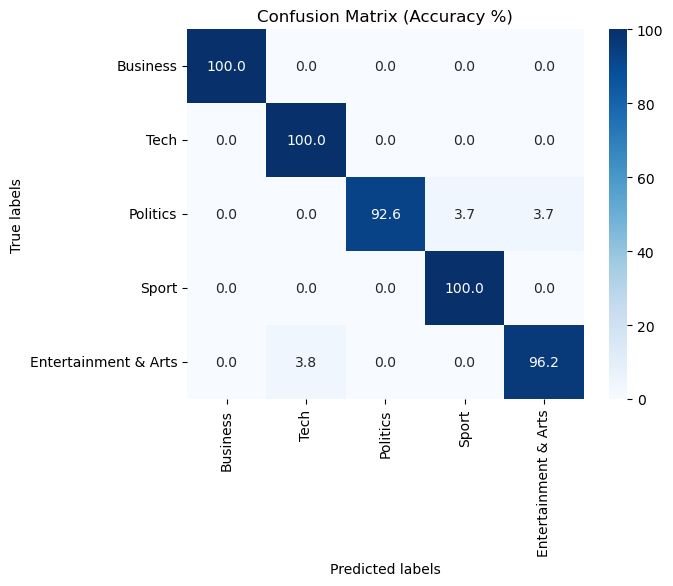

In [65]:
# Confusion matrix for accuracy

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have true labels and predicted labels for your test data
true_labels = y_test
predicted_labels = y_test_pred

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create a list of class labels (optional, if you have class labels)
class_labels = art_en_df["Category"].unique().tolist()  # List of class labels in the order of the confusion matrix

# Create a heatmap using seaborn
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.1f')

# Add labels, title, and axis ticks
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Accuracy %)')
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)

# Create tick labels with class names
tick_labels = class_labels
#tick_labels = [f'{class_labels[i]} ({i})' for i in range(len(class_labels))]
plt.xticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=0)

# Display the plot
plt.show()


# 6. Input classification

In [66]:
# Open model from file
import pickle
with open('my_en_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [67]:
# Load spaCy model for German
nlp = sp.load("en_core_web_sm")

# Input text for instant classification
input_text = input("Enter text: ")

# Clean input text
def preprocess_text_clean(text):
    clean_text = re.sub('<.*?>', '', text) # Remove HTML tags
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', clean_text) # remove special characters, numbers, and punctuation
    clean_text = clean_text.lower() # lowercasing
    clean_text = re.sub(r'\s+', ' ', clean_text) # remove extra whitespace
    return clean_text.strip()

#Lemmatize input text
def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# Replace characters of input text based on dict
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

processed_text = preprocess_text_clean(input_text)
processed_text = lemmatize_text(processed_text)
processed_text = replace_characters(processed_text)
processed_text = remove_stopwords(processed_text)

prediction = loaded_model.predict([processed_text])
print(f'\nTopic: {prediction[0]}')

Enter text:  The BBC is launching a brand new technology newsletter for international audiences, called Tech Decoded.  Why now?  Tech news isn't a speciality any more. It's just the news. AI, social media drama, Elon Musk's latest proclamations - it's all mainstream. But it differs from other types of news in one key way.  A wiser colleague than I, who covered the technology beat for years, once told me that editors always want an "iPhone moment", where someone walks out on a stage and reveals a brand new invention that will change our lives.  That can happen, but it's not normally how the industry works.  Take the current AI boom as an example. The technology behind ChatGPT was being developed for years before the current craze - and that's why GPT was already on version 3.5 by the time most people heard of it.  There's a much deeper development cycle that goes on before major companies start tacking the latest buzzword on every product they make. That's been true for all the tech hyp


Topic: Tech


In [71]:
# Perform prediction and get confidence scores (decision function values)
confidence_scores = loaded_model.decision_function([processed_text])[0]

# Get sorted list of categories
my_list=art_en_df["Category"].unique().tolist()
my_list = sorted(my_list)

# Create dict for storing category-score pairs
topic_dict = {}

# Print the confidence scores for each category
for category, score in zip(my_list, confidence_scores):
    #print(category, ": ", round(score, 3))
    if score > 0:
        topic_dict[category] = round(score, 3)
topic_dict_sorted = sorted(topic_dict.items(), key=lambda item: item[1], reverse=True)

print(topic_dict_sorted)

# Print classifications with positive score or, if not available, best classification
if len(topic_dict) == 0:
    print(f'\nTopic: {prediction[0]}')
else:
    for entry in topic_dict_sorted:
        print (f'\nTopic: {entry[0]}')


[('Tech', 0.214)]

Topic: Tech
